In [3]:
!pip install facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

In [1]:
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import PIL
import torch
import torchvision
from facenet_pytorch import MTCNN
from PIL import Image
from torchvision.utils import make_grid

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("PIL version : ", PIL.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
torch version :  2.2.2+cu121
torchvision version :  0.17.2+cu121
PIL version :  10.2.0


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


# MTCNN Model

In [4]:
MTCNN?

In [5]:
mtcnn = MTCNN(device=device, keep_all=True, min_face_size=60, post_process=False)

print(mtcnn)

MTCNN(
  (pnet): PNet(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=10)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=16)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (prelu3): PReLU(num_parameters=32)
    (conv4_1): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
    (softmax4_1): Softmax(dim=1)
    (conv4_2): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (rnet): RNet(
    (conv1): Conv2d(3, 28, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=28)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(28, 48, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=48)
    (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv3): Conv2d(48, 64,

In [6]:
extracted_frames_dir = "/content/drive/MyDrive/extracted_frames"
print(extracted_frames_dir)

/content/drive/MyDrive/extracted_frames


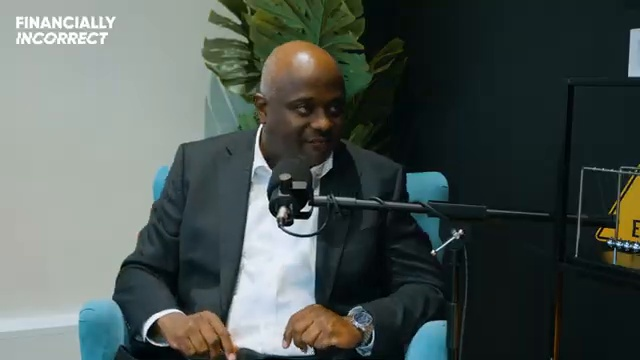

In [10]:
extracted_frames_dir = Path(extracted_frames_dir)

sample_image_filename = "frame_1000.jpg"
sample_image_path = extracted_frames_dir / sample_image_filename

sample_image = Image.open(sample_image_path)
sample_image

# Bounding Boxes

In [11]:
boxes, probs = mtcnn.detect(sample_image)

print("boxes type:", type(boxes))
print("probs type:", type(probs))

boxes type: <class 'numpy.ndarray'>
probs type: <class 'numpy.ndarray'>


In [12]:
print(boxes)
print(boxes.shape)

[[273.0382385253906 74.92679595947266 340.9615783691406
  161.47085571289062]]
(1, 4)


In [13]:
number_of_detected_faces = len(boxes)

print(number_of_detected_faces)

1


In [15]:
probs[probs > 0.99]

array([0.9999215602874756], dtype=object)

In [16]:
num_faces = len(probs[probs > 0.99])

print(num_faces)

1


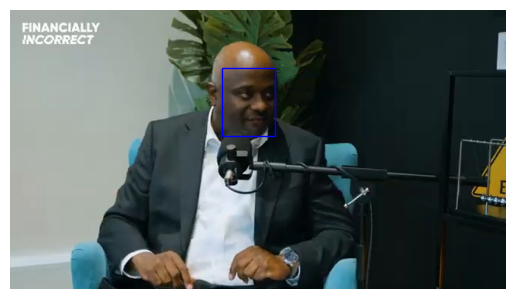

In [17]:
fig, ax = plt.subplots()
ax.imshow(sample_image)

for box in boxes:
    rect = plt.Rectangle(
        (box[0], box[1]), box[2] - box[0], box[3] - box[1], fill=False, color="blue"
    )
    ax.add_patch(rect)
plt.axis("off");

# Extracting Facial Landmarks

In [18]:
boxes, probs, landmarks = mtcnn.detect(sample_image, landmarks=True)

print("boxes type:", type(boxes))
print("probs type:", type(probs))
print("landmarks type:", type(landmarks))

boxes type: <class 'numpy.ndarray'>
probs type: <class 'numpy.ndarray'>
landmarks type: <class 'numpy.ndarray'>


In [19]:
print(landmarks.shape)

(1, 5, 2)


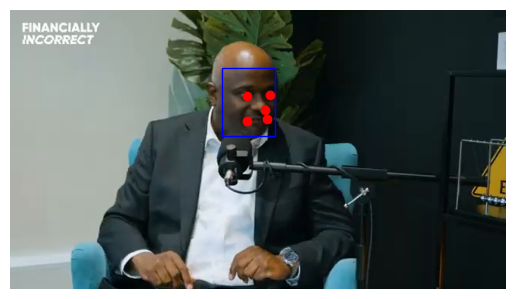

In [20]:
fig, ax = plt.subplots()
ax.imshow(sample_image)

for box, landmark in zip(boxes, landmarks):
    rect = plt.Rectangle(
        (box[0], box[1]), box[2] - box[0], box[3] - box[1], fill=False, color="blue"
    )
    ax.add_patch(rect)
    for point in landmark:
        ax.plot(point[0], point[1], marker="o", color="red")
plt.axis("off");

In [21]:
faces = mtcnn(sample_image)

print(faces.shape)

torch.Size([1, 3, 160, 160])


In [22]:
Grid = make_grid(faces, nrow=3)

print(Grid.shape)

torch.Size([3, 160, 160])


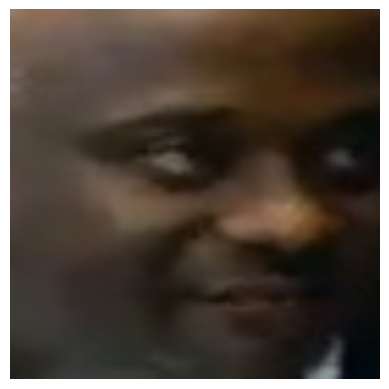

In [23]:
plt.imshow(Grid.permute(1, 2, 0).int())
plt.axis("off");

# Cosine Similarity For Sorting Photos


In [25]:
from facenet_pytorch import MTCNN, InceptionResnetV1

extracted_frames_dir = extracted_frames_dir


# Create categorized output folders
out_dirs = {
    "edward": Path("sorted_faces/edward_kirathe"),
    "barack": Path("sorted_faces/barack_bukusi"),
    "both": Path("sorted_faces/both_present"),
    "unknown": Path("sorted_faces/other_or_none")
}

for d in out_dirs.values():
    d.mkdir(parents=True, exist_ok=True)

# Load models

mtcnn = MTCNN(device=device, keep_all=True).eval()
resnet = InceptionResnetV1(pretrained="vggface2").eval().to(device)

def get_ref_embedding(img_path):
    """Helper to extract a single embedding from a reference image."""
    img = Image.open(img_path).convert("RGB")
    face = mtcnn(img)
    if face is None or len(face) == 0:
        raise ValueError(f"No face found in reference file: {img_path}")
    # Return embedding of the first (should be the only) face in the ref image
    with torch.no_grad():
        return resnet(face[0].unsqueeze(0).to(device))

# Generate target embeddings
print("Encoding reference faces...")
edward_emb = get_ref_embedding("/content/drive/MyDrive/extracted_frames/frame_1000.jpg")
barack_emb = get_ref_embedding("/content/drive/MyDrive/extracted_frames/frame_1855.jpg")

# 3. Processing Loop
similarity_threshold = 0.65

print(f"Starting classification of frames in {extracted_frames_dir}...")

for img_path in extracted_frames_dir.glob("*.jpg"):
    try:
        img = Image.open(img_path).convert("RGB")
        faces = mtcnn(img)

        if faces is not None and len(faces) > 0:
            with torch.no_grad():
                # Process all faces in frame at once
                frame_embs = resnet(faces.to(device))

            found_edward = False
            found_barack = False

            for emb in frame_embs:
                # Calculate similarity for this specific face
                sim_e = torch.nn.functional.cosine_similarity(edward_emb, emb.unsqueeze(0)).item()
                sim_b = torch.nn.functional.cosine_similarity(barack_emb, emb.unsqueeze(0)).item()

                if sim_e >= similarity_threshold:
                    found_edward = True
                if sim_b >= similarity_threshold:
                    found_barack = True

            # Sorting logic
            if found_edward and found_barack:
                shutil.copy(img_path, out_dirs["both"] / img_path.name)
            elif found_edward:
                shutil.copy(img_path, out_dirs["edward"] / img_path.name)
            elif found_barack:
                shutil.copy(img_path, out_dirs["barack"] / img_path.name)
            else:
                shutil.copy(img_path, out_dirs["unknown"] / img_path.name)
        else:
            # No face detected
            shutil.copy(img_path, out_dirs["unknown"] / img_path.name)

    except Exception as e:
        print(f"Skipping {img_path.name} due to error: {e}")

print("Sorting complete. Check the 'sorted_faces' folder.")

Encoding reference faces...
Starting classification of frames in /content/drive/MyDrive/extracted_frames...
Sorting complete. Check the 'sorted_faces' folder.


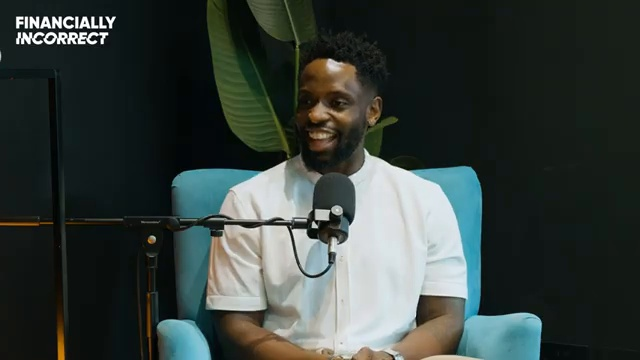

In [26]:
barack_bukusi = "/content/sorted_faces/barack_bukusi/frame_10230.jpg"
Image.open(barack_bukusi)

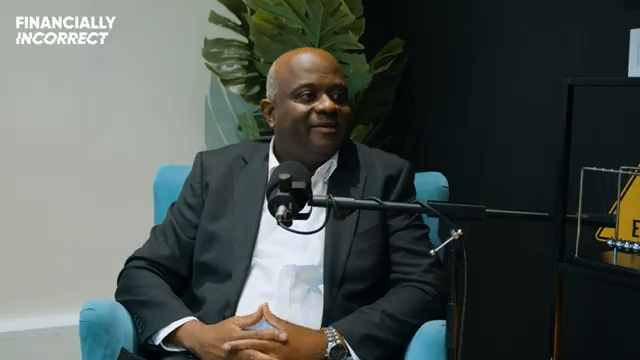

In [27]:
edward = "/content/sorted_faces/edward_kirathe/frame_10035.jpg"
Image.open(edward)

In [31]:
shutil.rmtree("/content/sorted_faces/other_or_none", ignore_errors=True)

In [33]:
shutil.rmtree("/content/sorted_faces/both_present",ignore_errors=True)

In [34]:
shutil.rmtree("/content/sorted_frames",ignore_errors=True)

In [35]:
from pathlib import Path
import shutil

# Define paths
local_frames_dir = Path(
    "/content/sorted_faces"
)  # Update if your folder has a different path
drive_dest_dir = Path(
    "/content/drive/MyDrive/sorted_faces"
)  # Destination in your Drive

# Copy or move the entire folder
if local_frames_dir.exists():
    # Use shutil.copytree to copy (or shutil.move to move)
    if drive_dest_dir.exists():
        shutil.rmtree(
            drive_dest_dir
        )  # Clean up old version in drive if it exists
    shutil.copytree(local_frames_dir, drive_dest_dir)
    print(f"Successfully uploaded frames to: {drive_dest_dir}")
else:
    print(f"Local folder '{local_frames_dir}' not found.")

Successfully uploaded frames to: /content/drive/MyDrive/sorted_faces


In [36]:
edward_kirathe_imgs = Path("/content/sorted_faces/edward_kirathe")

edward_kirathe_img_paths = list(edward_kirathe_imgs.glob("*.jpg"))

print("Number of images we'll use:", len(edward_kirathe_img_paths))

Number of images we'll use: 4793


In [37]:
barack_bukusi_imgs = Path("/content/sorted_faces/barack_bukusi")

barack_bukusi_img_paths = list(barack_bukusi_imgs.glob("*.jpg"))

print("Number of images we'll use:", len(barack_bukusi_img_paths))

Number of images we'll use: 1252


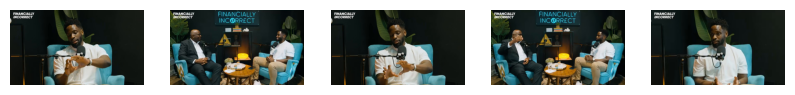

In [39]:
fig, axs = plt.subplots(1, 5, figsize=(10, 8))

for i, ax in enumerate(axs):
    ax.imshow(Image.open(barack_bukusi_img_paths[i]))
    ax.axis("off")

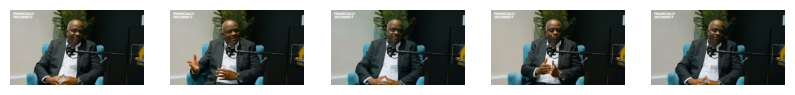

In [40]:
fig, axs = plt.subplots(1, 5, figsize=(10, 8))

for i, ax in enumerate(axs):
    ax.imshow(Image.open(edward_kirathe_img_paths[i]))
    ax.axis("off")